Since one of the datasets we chose was over 100mb, we split up the data prior to uploading to ensure it could be committed to our repository. These files are stored as AmazonData1.csv and AmazonData2.csv. Before performing any analysis on our data, we must read both of these files into DataFrames, then combine them into a single DataFrame.

In [3]:
%pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 49.5 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 56.0 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [numpy]  WARNING: The scripts f2py and numpy-config are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd

amazon1 = pd.read_csv('/workspaces/group-project-bas-team/data/AmazonData1.csv')
amazon2 = pd.read_csv('/workspaces/group-project-bas-team/data/AmazonData2.csv')

amazon_data = [amazon1, amazon2]

amazon = pd.concat(amazon_data)

In [7]:
amazon.info()

<class 'pandas.DataFrame'>
Index: 1048575 entries, 0 to 525575
Data columns (total 8 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Order Date                1048575 non-null  str    
 1   Purchase Price Per Unit   1048575 non-null  float64
 2   Quantity                  1048575 non-null  int64  
 3   Shipping Address State    997480 non-null   str    
 4   Title                     997060 non-null   str    
 5   ASIN/ISBN (Product Code)  1047967 non-null  str    
 6   Category                  997766 non-null   str    
 7   Survey ResponseID         1048575 non-null  str    
dtypes: float64(1), int64(1), str(6)
memory usage: 72.0 MB


In [ ]:
amazon.shape #8 columns and 1,048,575 observations

(1048575, 8)

In [9]:
amazon.head()

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID
0,12/4/2018,7.98,1,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,FLASH_MEMORY,R_01vNIayewjIIKMF
1,12/22/2018,13.99,1,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,HEADPHONES,R_01vNIayewjIIKMF
2,12/24/2018,8.99,1,NJ,NaN,B078JZTFN3,NaN,R_01vNIayewjIIKMF
3,12/25/2018,10.45,1,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,DISHWARE_BOWL,R_01vNIayewjIIKMF
4,12/25/2018,10.00,1,NJ,Proraso Shaving Cream for Men,B00837ZOI0,SHAVING_AGENT,R_01vNIayewjIIKMF


In [10]:
amazon.isnull().sum()

Order Date                      0
Purchase Price Per Unit         0
Quantity                        0
Shipping Address State      51095
Title                       51515
ASIN/ISBN (Product Code)      608
Category                    50809
Survey ResponseID               0
dtype: int64

In [11]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 37.5 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 43.7 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
from sklearn.impute import SimpleImputer

numeric_cols = amazon.select_dtypes(include=['int64', 'float64']).columns
num_imputer = SimpleImputer(strategy='mean')
amazon[numeric_cols] = num_imputer.fit_transform(amazon[numeric_cols])

categorical_cols = amazon.select_dtypes(include=['str']).columns
cat_imputer = SimpleImputer(strategy='most_frequent')
amazon[categorical_cols] = cat_imputer.fit_transform(amazon[categorical_cols])

In [14]:
amazon.isnull().sum()

Order Date                  0
Purchase Price Per Unit     0
Quantity                    0
Shipping Address State      0
Title                       0
ASIN/ISBN (Product Code)    0
Category                    0
Survey ResponseID           0
dtype: int64

In [15]:
#Dropping any duplicate values
amazon = amazon.drop_duplicates()

In [16]:
#Summary statistics
amazon.describe(include='all') #"include='all'" ensures categorical columns are included

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID
count,1042117,1.042117e+06,1.042117e+06,1042117,1042117,1042117,1042117,1042117
unique,1913,NaN,NaN,52,532039,596782,1816,2846
top,7/12/2022,NaN,NaN,CA,Amazon.com Gift Card Balance Reload,B00IX1I3G6,ABIS_BOOK,R_24csoaO569P4Yzz
freq,2754,NaN,NaN,149612,56307,5546,100259,4733
mean,NaN,2.272786e+01,1.084998e+00,NaN,NaN,NaN,NaN,NaN
std,NaN,4.554914e+01,5.871669e-01,NaN,NaN,NaN,NaN,NaN
min,NaN,1.000000e-02,1.000000e+00,NaN,NaN,NaN,NaN,NaN
25%,NaN,8.590000e+00,1.000000e+00,NaN,NaN,NaN,NaN,NaN
50%,NaN,1.399000e+01,1.000000e+00,NaN,NaN,NaN,NaN,NaN
75%,NaN,2.384000e+01,1.000000e+00,NaN,NaN,NaN,NaN,NaN


Most of these columns are categorical so obviously there's gonna be NaN values where it asks for mean, SD, and any numeric calculations.

In [17]:
%pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 48.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 46.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 41.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 53.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━ 3/7 [fonttools]  WARNING: The scripts fonttools, pyftmerge, pyftsubset and ttx are installed in '/usr/local/python/3.12.1/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
%pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


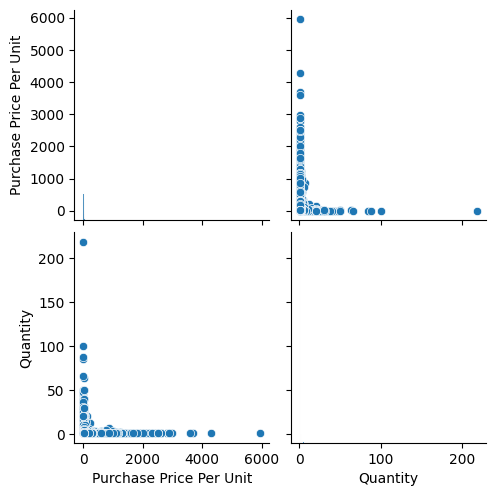

In [20]:
import seaborn as sns

sns.pairplot(amazon)

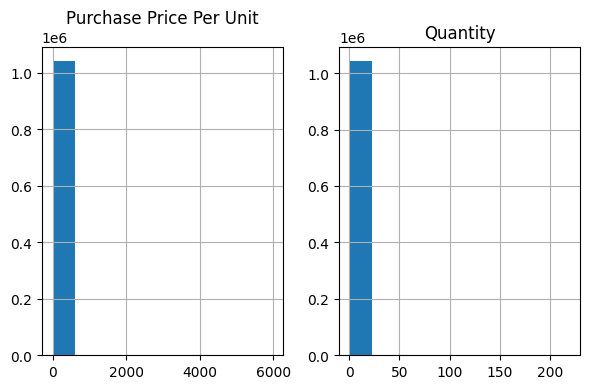

In [ ]:
import matplotlib.pyplot as plt

amazon.hist(figsize=(6,4))
plt.tight_layout()
plt.show()

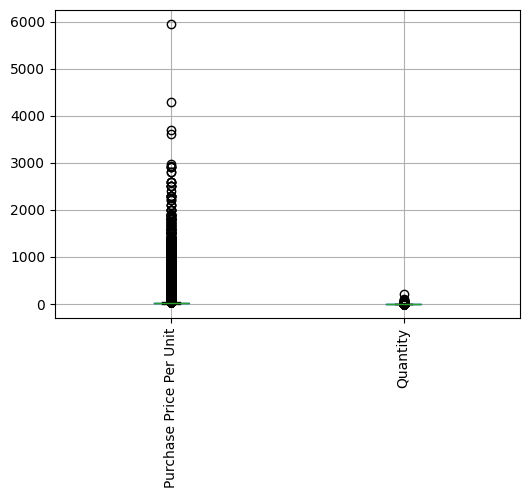

In [ ]:
#Check for outliers in numeric columns
amazon.boxplot(figsize=(6,4))
plt.xticks(rotation=90)
plt.show()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51],
 [Text(0, 0, 'NJ'),
  Text(1, 0, 'CA'),
  Text(2, 0, 'PA'),
  Text(3, 0, 'VT'),
  Text(4, 0, 'AK'),
  Text(5, 0, 'VA'),
  Text(6, 0, 'SD'),
  Text(7, 0, 'MN'),
  Text(8, 0, 'ID'),
  Text(9, 0, 'NE'),
  Text(10, 0, 'WY'),
  Text(11, 0, 'NC'),
  Text(12, 0, 'OH'),
  Text(13, 0, 'LA'),
  Text(14, 0, 'OK'),
  Text(15, 0, 'UT'),
  Text(16, 0, 'FL'),
  Text(17, 0, 'CO'),
  Text(18, 0, 'KS'),
  Text(19, 0, 'TX'),
  Text(20, 0, 'WI'),
  Text(21, 0, 'GA'),
  Text(22, 0, 'MA'),
  Text(23, 0, 'TN'),
  Text(24, 0, 'MD'),
  Text(25, 0, 'MI'),
  Text(26, 0, 'IL'),
  Text(27, 0, 'IN'),
  Text(28, 0, 'WA'),
  Text(29, 0, 'AZ'),
  Text(30, 0, 'WV'),
  Text(31, 0, 'IA'),
  Text(32, 0, 'OR'),
  Text(33, 0, 

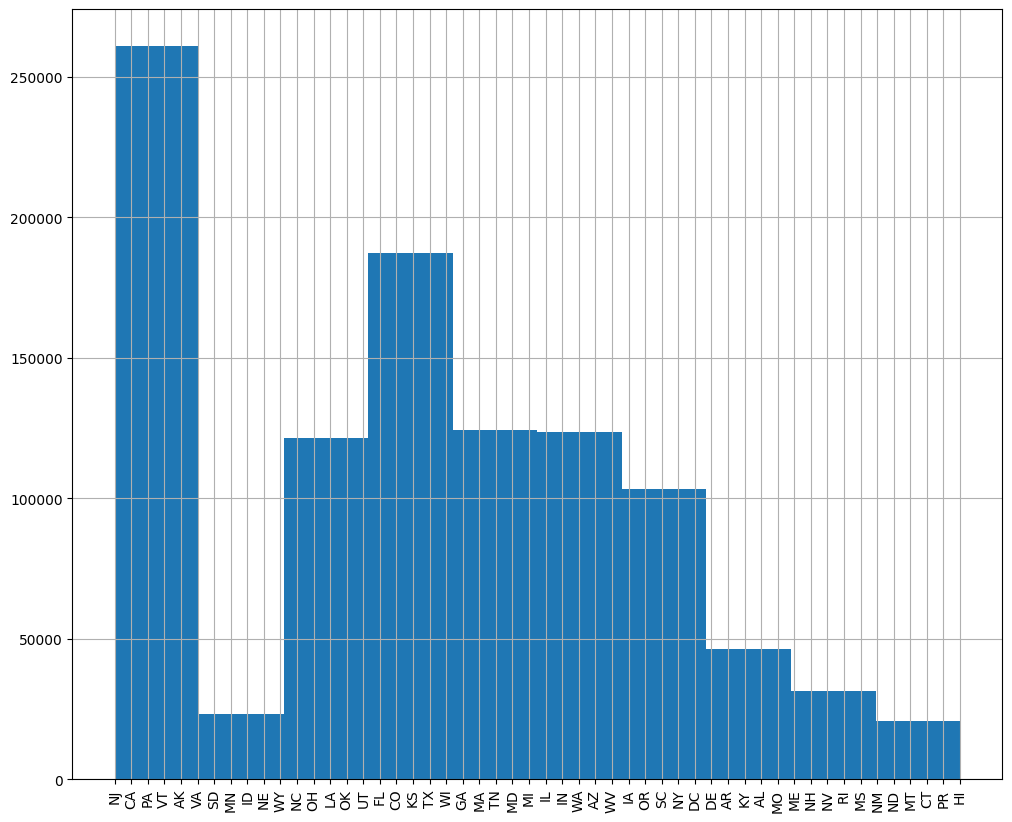

In [30]:
amazon['Shipping Address State'].hist(figsize=(12,10)) 
plt.xticks(rotation=90)